<a href="https://colab.research.google.com/github/winengewe/movie-revenue-prediction/blob/main/movie_revenue_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Exercise 1 - Movies**
1.Load and view the data

2.Check the file and Clean if needed

3.Check for correlation links with Budget ( use numeric data only )

4.Set your x and y  and convert to Numpy

5.Visualise any data that is correlated above 0.6 with Budget as a scatter chart

6.Split data into 80% Training & 20% Test

7.Create a Linear model using training set - reshape if needed

8.Check the model using 20% Test

9.Score the model

10.Visualise the actual and predicted data on same chart

11.Would you recommend this model ?

12.Decide if model is valid or not

In [ ]:
# import libraries
from google.colab import drive
drive.mount('/content/gdrive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Mounted at /content/gdrive


In [ ]:
# 1.Load and view the data
df = pd.read_csv('gdrive/My Drive/GC NPA AI 2025/revenue-1.csv')
print(df.head()) # look at data
print(df.info())
print(df.describe())

                                    Title    Budget     ID Original Language  \
0                            The Woodsman         0   9692                en   
1  Alesha Popovich and Tugarin the Dragon   4000000  33065                ru   
2                        Meet the Fockers  80000000    693                en   
3                               Spanglish  80000000   2539                en   
4                   Flight of the Phoenix  45000000  11866                en   

   Popularity Release Date    Revenue  Runtime  Vote Average  Vote Count  
0    6.984903   24/12/2004    4678405       87           6.9         106  
1    1.760091   23/12/2004    1730000       72           6.1          20  
2   11.876386   22/12/2004  516642939      115           6.1        1412  
3   11.202764   17/12/2004   55041367      130           5.8         375  
4   15.434731   17/12/2004   21009180      113           5.7         282  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 922 entries, 0 to 9

In [ ]:
# 2.Check the file and Clean if needed
print("\nMissing values:\n", df.isnull().sum()) # Show the total of missing values for each column


Missing values:
 Title                0
Budget               0
ID                   0
Original Language    0
Popularity           0
Release Date         0
Revenue              0
Runtime              0
Vote Average         0
Vote Count           0
dtype: int64


In [ ]:
# 3.Check for correlation links with Budget ( use numeric data only )
df.corr(numeric_only=True)

,Budget,ID,Popularity,Revenue,Runtime,Vote Average,Vote Count
Budget,1.000000,-0.304390,0.500413,0.674796,0.268639,0.031325,0.507976
ID,-0.304390,1.000000,-0.472183,-0.258621,-0.142571,-0.344603,-0.263773
Popularity,0.500413,-0.472183,1.000000,0.621341,0.215228,0.310779,0.695313
Revenue,0.674796,-0.258621,0.621341,1.000000,0.273830,0.204700,0.832335
Runtime,0.268639,-0.142571,0.215228,0.273830,1.000000,0.334533,0.277990
Vote Average,0.031325,-0.344603,0.310779,0.204700,0.334533,1.000000,0.335935
Vote Count,0.507976,-0.263773,0.695313,0.832335,0.277990,0.335935,1.000000


In [ ]:
# 4.Set your x and y and convert to Numpy
x=df[['Budget']].to_numpy()
y=df[['Revenue']].to_numpy()

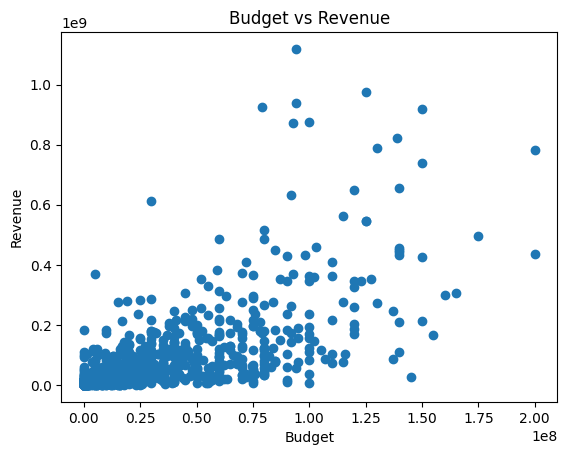

In [ ]:
# 5.Visualise any data that is correlated above 0.6 with Budget as a scatter chart
plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.scatter(x,y)
plt.show()

In [ ]:
# 6.Split data into 80% Training & 20% Test
split=int(0.8*len(df)) # find a 80% value so we can use to split data nto Train & Test
x_train=x[:split] # split data to create training set from start of data to 80%
y_train=y[:split] # split data to create training set from start of data to 80%
x_test=x[split:]  # split data to create test set from 80% to end of data
y_test=y[split:]  # split data to create test set from 80% to end of data

In [ ]:
# 7.Create a Linear model using training set - reshape if needed
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
# 8.Check the model using 20% Test
y_pred_test=model.predict(x_test)
# print(y_pred)

y_pred_train=model.predict(x_train)

In [ ]:
# 9.Score the model
print(model.score(x_train,y_train))
print(model.score(x_test,y_test))

print(model.score(x_train,y_pred_train))
print(model.score(x_test,y_pred_test))

0.9741805909739772
0.6437434974464114
1.0
1.0


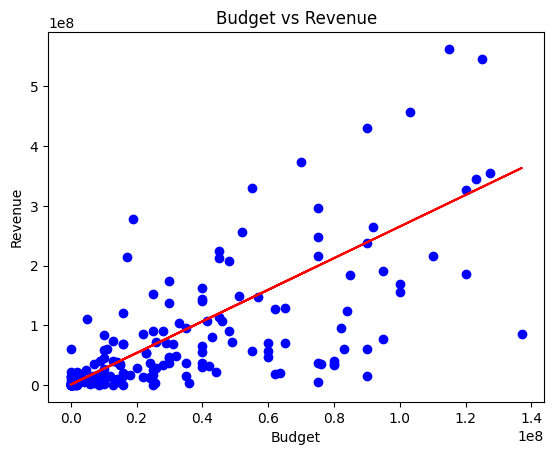

In [ ]:
# 10.Visualise the actual and predicted data on same chart
plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.scatter(x_test,y_test,color='blue')
plt.plot(x_test,y_pred,color='red')

In [ ]:
# 11.Would you recommend this model ?
print('No, because the model has score <0.8, budget and revenue does not have high correlation')

No, because the model has score <0.8, budget and revenue does not have high correlation


In [ ]:
# 12.Decide if model is valid or not
print('not valid, based on the answers in Q11')

not valid, based on the answers in Q11


# Decision Tree

1.0
0.42269267427690604


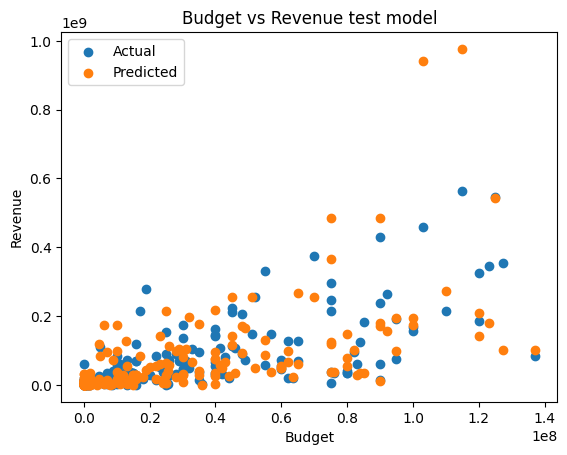

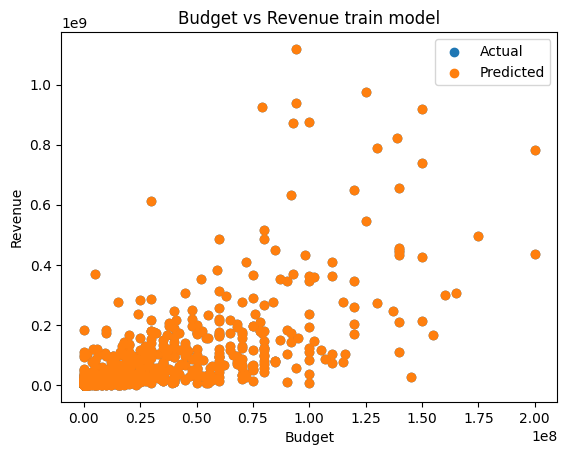

In [ ]:
x = df.drop(columns=['Title','Original Language','Release Date','Revenue']).to_numpy()
# x = df.drop(columns=['quality']),to_numpy() # set the x values as all except quality
y=df[['Revenue']].to_numpy()

split=int(0.8*len(df)) # find a 80% value so we can use to split data into Train & Test
x_train=x[:split] # split data to create training set from start of data to 80%
y_train=y[:split] # split data to create training set from start of data to 80%
x_test=x[split:]  # split data to create test set from 80% to end of data
y_test=y[split:]  # split data to create test set from 80% to end of data

from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor()
model.fit(x_train,y_train)

y_pred_train=model.predict(x_train) # predict the model using train data
print(model.score(x_train,y_train))
y_pred_test=model.predict(x_test) # predict the model using test data
print(model.score(x_test,y_test))

#plt.scatter(x_train[:,0],x_train[:,1],alpha=0.2,c=y_pred_train,cmap='jet')
#plt.show()
#plt.scatter(x_test[:,0],x_test[:,1],alpha=0.2,c=y_pred_test,cmap='jet')
#plt.show()

plt.scatter(x_test[:,0],y_test)
plt.scatter(x_test[:,0],y_pred_test)
plt.title('Budget vs Revenue test model')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.legend(['Actual','Predicted'])
plt.show()

plt.scatter(x_train[:,0],y_train)
plt.scatter(x_train[:,0],y_pred_train)
plt.title('Budget vs Revenue train model')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.legend(['Actual','Predicted'])
plt.show()


# Random Forest

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Train model score:  0.9734942120206794
Test model score:  0.6526256934130208


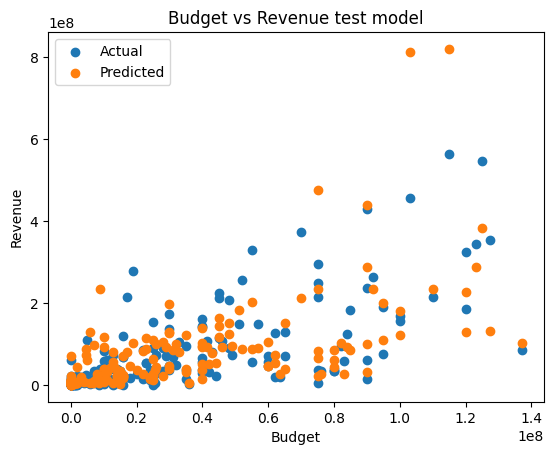

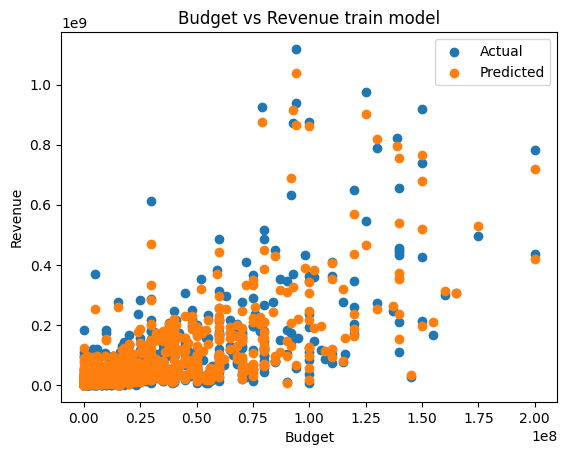

In [ ]:
#x = df.drop(columns=['Title','Original Language','Release Date','Revenue']).to_numpy()
x=df[['Budget','Popularity','Runtime','Vote Average','Vote Count']].to_numpy() # set the x values
# x = df.drop(columns=['quality']),to_numpy() # set the x values as all except quality
y=df[['Revenue']].to_numpy()

split=int(0.8*len(df)) # find a 90% value so we can use to split data into Train & Test
x_train=x[:split] # split data to create training set from start of data to 90%
y_train=y[:split] # split data to create training set from start of data to 90%
x_test=x[split:]  # split data to create test set from 90% to end of data
y_test=y[split:]  # split data to create test set from 90% to end of data

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100,random_state=42) #default estimators = 100
model.fit(x_train,y_train)

y_pred_train=model.predict(x_train)
print("Train model score: ",model.score(x_train,y_train))
y_pred_test=model.predict(x_test)
print("Test model score: ",model.score(x_test,y_test))

#plt.scatter(x_train[:,0],x_train[:,1],alpha=0.2,c=y_pred_train,cmap='jet')
#plt.show()
#plt.scatter(x_test[:,0],x_test[:,1],alpha=0.2,c=y_pred_test,cmap='jet')
#plt.show()

plt.scatter(x_test[:,0],y_test)
plt.scatter(x_test[:,0],y_pred_test)
plt.title('Budget vs Revenue test model')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.legend(['Actual','Predicted'])
plt.show()

plt.scatter(x_train[:,0],y_train)
plt.scatter(x_train[:,0],y_pred_train)
plt.title('Budget vs Revenue train model')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.legend(['Actual','Predicted'])
plt.show()


The model is more visually appealing as the points are more widely distributed.

# Compare different Random Forest split

In [ ]:
split=int(0.7*len(df)) # find a 90% value so we can use to split data into Train & Test
x_train=x[:split] # split data to create training set from start of data to 90%
y_train=y[:split] # split data to create training set from start of data to 90%
x_test=x[split:]  # split data to create test set from 90% to end of data
y_test=y[split:]  # split data to create test set from 90% to end of data

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100,random_state=42) #default estimators = 100
model.fit(x_train,y_train)

y_pred_train=model.predict(x_train)
print("Train model score 70: ",model.score(x_train,y_train))
y_pred_test=model.predict(x_test)
print("Test model score 30: ",model.score(x_test,y_test))

split=int(0.8*len(df)) # find a 90% value so we can use to split data into Train & Test
x_train=x[:split] # split data to create training set from start of data to 90%
y_train=y[:split] # split data to create training set from start of data to 90%
x_test=x[split:]  # split data to create test set from 90% to end of data
y_test=y[split:]  # split data to create test set from 90% to end of data

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100,random_state=42) #default estimators = 100
model.fit(x_train,y_train)

y_pred_train=model.predict(x_train)
print("Train model score 80: ",model.score(x_train,y_train))
y_pred_test=model.predict(x_test)
print("Test model score 20: ",model.score(x_test,y_test))

split=int(0.8*len(df)) # find a 90% value so we can use to split data into Train & Test
x_train=x[:split] # split data to create training set from start of data to 90%
y_train=y[:split] # split data to create training set from start of data to 90%
x_test=x[split:]  # split data to create test set from 90% to end of data
y_test=y[split:]  # split data to create test set from 90% to end of data

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=1000,random_state=42) #default estimators = 100
model.fit(x_train,y_train)

y_pred_train=model.predict(x_train)
print("Train model score 90: ",model.score(x_train,y_train))
y_pred_test=model.predict(x_test)
print("Test model score 10: ",model.score(x_test,y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Train model score 70:  0.9739021912477487
Test model score 30:  0.7159426101928239


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Train model score 80:  0.9734942120206794
Test model score 20:  0.6526256934130208


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Train model score 90:  0.9741805909739772
Test model score 10:  0.6437434974464114


# Feature Enginnering
use random forest model to predict how much min,max,average revenue from input budget

In [ ]:
# 12.Use the model eg1
print("Mean Budget: £ ",round(df['Budget'].mean(),2))
print("Mean Revenue: £ ",round(df['Revenue'].mean(),2))

budget = float(input("Enter projected movie budget : £ "))

# we are using the mean values in model to predict a revenue
predict_Revenue_average = model.predict(np.array([[budget,df['Popularity'].mean(),df['Runtime'].mean(),df['Vote Average'].mean(),df['Vote Count'].mean()]]))
# we are using the min values in model to predict a revenue
predict_Revenue_min = model.predict(np.array([[budget,df['Popularity'].min(),df['Runtime'].min(),df['Vote Average'].min(),df['Vote Count'].min()]]))
# we are using the max values in model to predict a revenue
predict_Revenue_max = model.predict(np.array([[budget,df['Popularity'].max(),df['Runtime'].max(),df['Vote Average'].max(),df['Vote Count'].max()]]))

print()
print("Your predicted average Revenue is : £ ",round(predict_Revenue_average[0],2))
print()
print("Your predicted min Revenue is : £ ",round(predict_Revenue_min[0],2))
print()
print("Your predicted max Revenue is : £ ",round(predict_Revenue_max[0],2))
print()


# print the predicted score stored at position 0 and round to 2 decimal places

Mean Budget: £  31406659.73
Mean Revenue: £  81026169.19


KeyboardInterrupt: Interrupted by user